# Spam Email Detection using Machine Learning

## Objective

The objective of this project is to classify SMS messages as Spam or Ham using Machine Learning and explain the prediction using a Large Language Model (Gemini).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("spam.csv", encoding="latin-1")

df.rename(columns={
    "v1": "label",
    "v2": "message"
}, inplace=True)

df.isnull().sum()

,0
label,0
message,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


### Missing Value Analysis

The `label` and `message` columns contain no missing values, which means every SMS message has a corresponding class label. The additional `Unnamed` columns contain a large number of missing values and are not useful for spam detection. These columns will be removed during data cleaning to simplify the dataset.

In [2]:
df.duplicated().sum()

np.int64(403)

### Checking Duplicate Records

Duplicate records can affect the quality of a machine learning model by giving repeated importance to the same examples. Using `duplicated().sum()`, we found that the dataset contains 403 duplicate rows. These duplicates will be removed during data cleaning to improve the quality of the dataset.

In [3]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
df.columns

Index(['label', 'message'], dtype='object')

In [4]:
df = df.drop_duplicates()
df["label"].value_counts()

,count
label,
ham,4516
spam,653


### Duplicate Record Removal

The dataset initially contained 403 duplicate records. Duplicate rows can introduce bias because the machine learning model repeatedly learns the same examples. These duplicates were removed using the `drop_duplicates()` function, reducing the dataset to 5169 unique SMS messages.

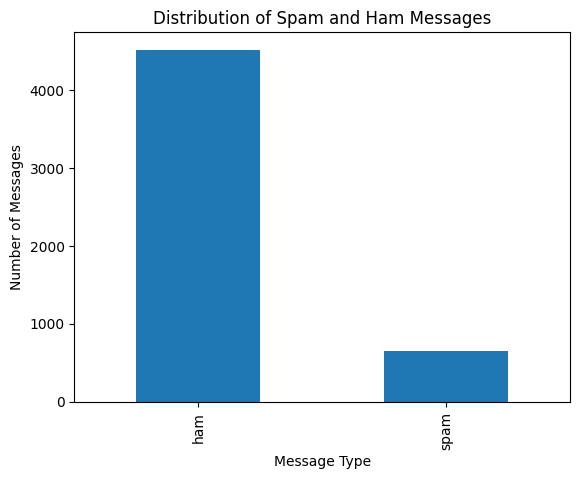

In [5]:
df["label"].value_counts().plot(kind="bar")
df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

### Bar Chart of Message Distribution

A bar chart was created to visualize the number of Ham and Spam messages in the dataset. The chart clearly shows that Ham messages are much more common than Spam messages. This indicates that the dataset is imbalanced, which is an important consideration when building and evaluating a machine learning model.

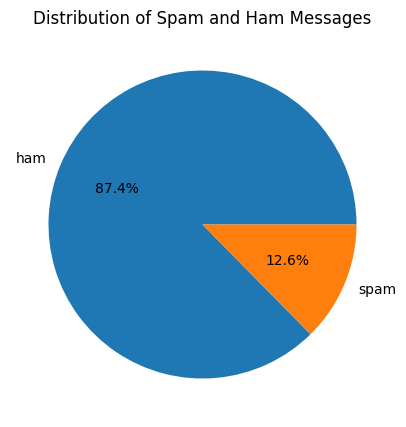

In [6]:
df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5,5)
)

plt.title("Distribution of Spam and Ham Messages")
plt.ylabel("")   # Removes the extra 'label' text
plt.show()

### Pie Chart of Message Distribution

A pie chart was created to show the proportion of Ham and Spam messages in the dataset. It provides a quick visual representation of the class distribution. The chart shows that Ham messages make up the majority of the dataset, while Spam messages form a much smaller portion.

In [7]:
!pip install wordcloud

In [8]:
from wordcloud import WordCloud

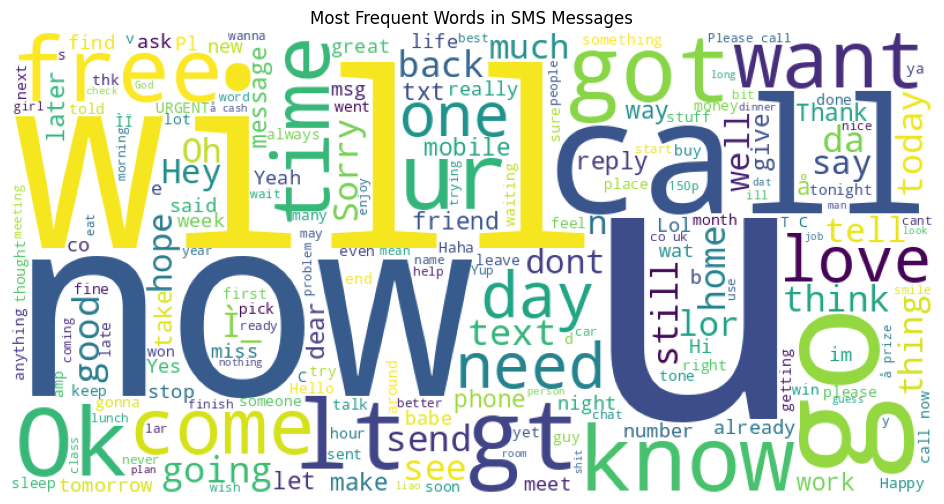

In [9]:
text = " ".join(df["message"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in SMS Messages")
plt.show()

### Word Cloud Visualization

A Word Cloud was generated to display the most frequently occurring words in the SMS dataset. Larger words represent higher frequency, while smaller words appear less often. This visualization helps identify common terms present in the messages and provides insights into the text data before preprocessing. Common words such as "u", "call", and "free" appear frequently, indicating that text preprocessing will be necessary before training the machine learning model.

# Text Preprocessing

### Step 1: Convert Text to Lowercase

The first preprocessing step is converting all SMS messages to lowercase. This ensures that words such as "FREE", "Free", and "free" are treated as the same word by the machine learning model. Converting text to lowercase reduces unnecessary variation in the dataset and improves consistency.

In [10]:
df["message"] = df["message"].str.lower()
df["message"].head()

,message
0,"go until jurong point, crazy.. available only ..."
1,ok lar... joking wif u oni...
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor... u c already then say...
4,"nah i don't think he goes to usf, he lives aro..."


### Step 2: Tokenization

Tokenization is the process of splitting a sentence into individual words or tokens. It converts a single text string into a list of smaller units, making it easier to perform further preprocessing tasks such as removing stop words, stemming, and feature extraction. NLTK's `word_tokenize()` function was used to tokenize the text.

In [11]:
!pip install nltk


In [12]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
from nltk.tokenize import word_tokenize

In [14]:
df["message"] = df["message"].apply(word_tokenize)


### Step 3: Remove Special Characters

After tokenization, each message is represented as a list of words (tokens). This step removes unnecessary special characters and punctuation from each token while preserving letters and numbers. Clean text improves the quality of features extracted for machine learning.

In [15]:
def remove_special_characters(tokens):
    cleaned_tokens = []

    for token in tokens:
        cleaned_token = ""

        for char in token:
            if char.isalnum():
                cleaned_token += char

        if cleaned_token != "":
            cleaned_tokens.append(cleaned_token)

    return cleaned_tokens

In [16]:
df["message"] = df["message"].apply(remove_special_characters)

### Step 4: Remove Stop Words

Stop words are commonly used words such as "the", "is", "a", and "to" that usually do not contribute much to identifying whether a message is spam or ham. Removing them helps the machine learning model focus on more meaningful words.

In [17]:
from nltk.corpus import stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
def remove_stopwords(tokens):
    filtered_tokens = []
    for token in tokens:
        if token not in stopwords.words("english"):
            filtered_tokens.append(token)

    return filtered_tokens

In [19]:
df["message"] = df["message"].apply(remove_stopwords)

### Step 5: Stemming

Stemming reduces words to their root form by removing prefixes or suffixes. This helps group similar words together, reducing the vocabulary size and improving the performance of the machine learning model.

In [20]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [21]:
def stem_tokens(tokens):
    stemmed_tokens = []

    for token in tokens:
        stemmed_tokens.append(ps.stem(token))

    return stemmed_tokens

In [22]:
df["message"] = df["message"].apply(stem_tokens)